# Demonstração de Aplicação do QDMC para o CSTR de van de Vusse

Rafael Ferreira Cavalcante

<rcavalcante@peq.coppe.ufrj.br>

O CSTR de van de Vusse é um benchmark classico de controle definido pelo seguinte sistema,

<p align="center">
  <img src="vdV2.svg" width="350">
</p>
Nesse sistema são processadas reações químicas em sequência e em paralelo:
$$
\begin{align*}
&\ce{A ->[$k_1$] B ->[$k_2$] C} \\
&\ce{2A ->[$k_3$] D}
\end{align*}
$$

*É comum que se deseje maximizar a produção de $B$*.

O sistema é modelado por um conjunto de equações diferenciais não lineares que descrevem os balanços de massa, os balanços de energia e a cinética do processo:

$$
\begin{align*}
&\frac{\mathrm{d}c_{\scriptscriptstyle A}}{\mathrm{d}t} = {\frac{F}{V}}\left({c_{\scriptscriptstyle A_{in}}}-c_{\scriptscriptstyle A}\right)-k_1(T)c_{\scriptscriptstyle A}-k_3(T)c_{\scriptscriptstyle A}^2 \\[2.5ex]
&\frac{\mathrm{d}{c_{\scriptscriptstyle B}}}{\mathrm{d}t} = - {\frac{F}{V}} \, {c_{\scriptscriptstyle B}}+k_1(T)c_{\scriptscriptstyle A}-k_2(T)c_{\scriptscriptstyle B} \\[2.5ex]
    &\begin{split}
        \frac{\mathrm{d}{T}}{\mathrm{d}t} & = \frac{1}{\rho C_p V} \Big[k_1(T)c_{\scriptscriptstyle A}(-\Delta H_{R_{AB}})+k_2(T)c_{\scriptscriptstyle B}(-\Delta H_{R_{BC}}) \\[2.5ex]
        & +k_3(T)c_{\scriptscriptstyle A}^2(-\Delta H_{R_{AD}})\Big] + \displaystyle{\frac{F}{V}}({T_{in}}-{T})+\frac{k_j A_R}{\rho C_p V}(T_k-{T})
    \end{split} \\[2.5ex]
&\frac{\mathrm{d}T_j}{\mathrm{d}t} = \frac{1}{m_jC_{p_j}} \left[
{\dot{Q}} + k_j A_R ({T} - T_j)
\right]
\end{align*}
$$

Nesse sistema as variáveis de estado são: 
$$
\mathbf{x} = \begin{bmatrix}
c_A \\
c_B \\
T \\
T_j
\end{bmatrix}
$$

em que:
- $c_A$ é a concentração do reagente $A$;
- $c_B$ é a concentração do reagente $B$;
- $T$ é a temperatura do reator;
- $T_j$ é a temperatura da camisa de resfriamento;

Para objetivos de controle, estamos interessados em controlar a concentração de B e a temperatura do reator, de modo que o vetor de variáveis controladas é dado por:
$$\mathbf{y} = \begin{bmatrix}
c_B \\
T \\
\end{bmatrix}
$$

enquanto as variáveis manipuladas são a razão $F/V$ e o calor retirado pela camisa $Q$, de modo que o vetor de variáveis manipuladas é dado por:
$$\mathbf{u} = \begin{bmatrix}
F/V \\
Q \\
\end{bmatrix}$$

Esse sistema é muito estudado como benchmark de controle por conta de, apesar de  sua modelagem simples, apresentar características de *inversão de ganho*, *resposta inversa* e *mudança no tempo de acomodação*.

### Objetivos

Aprender o uso dos códigos desse repositório para:
- Realizar o teste ao degrau em um sistema;
- Utilizar o resultado do teste ao degrau para construir o modelo de resposta ao degrau;
- Criar e sintonizar o controlador QDMC;
- Simular o controle do CSTR de van de Vusse em malha fechada com o QDMC;

Case seja necessário copiar o repositório do github

In [41]:
 !git clone https://github.com/rcavalcante00/qdmc-toolkit
 %cd qdmc-toolkit

 %pip install -r requirements.txt

Importação das bibliotecas básicas

In [42]:
import numpy as np                  # numpy para algébra
import matplotlib.pyplot as plt     # pyplot para fazer gráficos
from tqdm import tqdm               # tqdm para monitorar o progresso de loops

from src.VdV import VdV, VdVParams, base_par    # CSTR de van de Vusse definido em numpy

#### 1. Teste ao degrau.
#### 1.1 Obtenção do estado estacionário de referência

A primeira coisa que precisamos fazer para obter um modelo de resposta ao degrau para uso em um controlador preditivo é definir um estado estacionário de referência. A partir desse estado de referência, podemos realizar o teste ao degrau, manipulando as variáveis de entrada do sistema e observando/coletando a resposta das variáveis de saída, para a posterior construção da matriz dinâmica.

Para obter um estado estacionário de referência, precisamos escolher um ponto nominal para das variáveis entrada, para o CSTR de van de Vusse vamos escolher `u_nom = [20.0, -2.0]` que corresponde a $F/V = 20$ e $Q = -2.0$. Após isso, precisamos identificar o valor estacionário das variáveis de saída que correspondem a esse ponto nominal. Isso pode ser feito de duas formas:

- realizando a integração numérica do sistema até ele atingir o estado estacionário;
- resolvendo o sistema não linear do modelo do processo.

Vamos realizar os dois procedimentos a seguir.

Vamos definir primeiro nossa planta para poder trabalhar com ela.

In [43]:
params0 = VdVParams(**base_par)     # parâmetros do modelo que estão definidos no dicionário base_par
Plant = VdV(params0)                # criação do objeto representando o CSTR

Para realizar a integração numérica, vamos usar o método `integrate` disponível na classe `VdV.py`.

In [44]:
# condições iniciais quaisquer para fazer a integração numérica
x0 = [5.1, 0.0, 130, 130]

# valores nominais das entradas
# aqui o valor de 130 corresponde a temperatura da alimentação, que é tratada como um distúrbio medido
u_nom = [20.0, -2.0, 130]

# intervalo de integração em horas
t_span = [0, 1]    

# chamada da integração numérica
t, Y, U = Plant.integrate(t_span=t_span, y0=x0, u=u_nom)

No resultado da integração `t` guarda os valores de tempo da integração numérica, `Y` guarda os valores das saídas integradas e `U` os valores das entradas que foram usadas para fazer a integração.

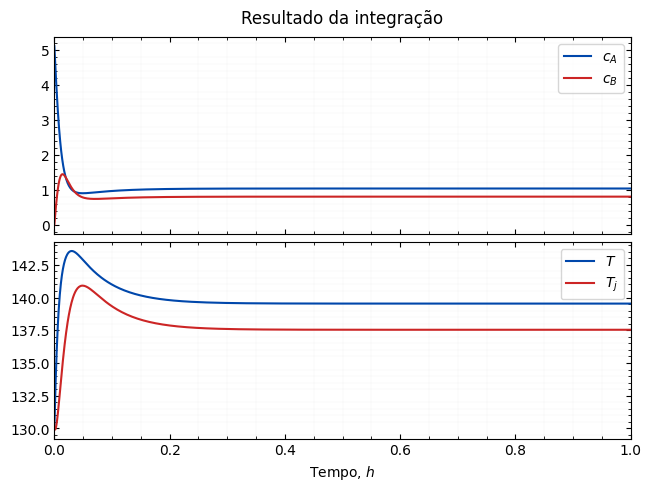

In [45]:
fig, ax = plt.subplots(2, 1, constrained_layout=True, sharex=True)

ax[0].plot(t, Y.T[0], label="$c_A$", color="#0047AB")
ax[0].plot(t, Y.T[1], label="$c_B$", color="#cc2525")

ax[1].plot(t, Y.T[2], label="$T$", color="#0047AB")
ax[1].plot(t, Y.T[3], label="$T_j$", color="#cc2525")

for a in ax:
    a.tick_params(axis='both', which='both',direction='in', top=True, right=True)
    a.autoscale(enable=True, axis='x', tight=True)

    a.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    a.minorticks_on()

ax[0].legend()
ax[1].legend()

ax[1].set_xlabel("Tempo, $h$")

ax[0].set_title("Resultado da integração", pad=10)

plt.show()

As figuras das curvas de $c_A$, $c_B$, $T$ e $T_j$ mostram como o sistema evolui dinamicamente a partir das condições iniciais `x0 = [5.1, 0.0, 130, 130]` até o estado estacionário.

Para acessar os valores do estado estacionário, basta pegar o último valor do vetor `Y` que contém os valores das variáveis de saída.

In [46]:
print(f"Estado estacionário: {Y[-1]}")

Estado estacionário: [  1.03617957   0.80396397 139.53788821 137.53788827]


O estado estacionário do sistema também poderia ser obtido resolvendo as equações do modelo do processo. O código `VdV.py` possui o método `steady_state` para o cálculo de estado estacionário que utiliza essa abordagem. Na sintaxe do método só precisamos informar um chute inicial para as variáveis de estado/saída e o valor das variáveis de entrada para as quais queremos obter o estado estacionário do sistema.

In [47]:
# vamos utilizar como chute inicial os mesmos valores da condição inicial de integração numérica
ss = Plant.steady_state(x0=x0, u=u_nom)

print(f"Estado estacionário: {ss}")

Estado estacionário: [  1.03617958   0.80396398 139.53788795 137.53788795]


*Os resultados obtidos pelos dois métodos são quase iguais, a diferença nas casas decimais acontece por causa de erros de arredondamento e truncamento.*

Por fim podemos verificar se esse estado é realmente "estacionário" fazendo novamente a integração numérica do sistema, mas dessa vez utilizando como condições iniciais os valores que encontramos anteriormente.

Vamos agora definir um vetor `x_nom =[1.03617958, 0.80396398, 139.53788795, 137.53788795]` e utilizá-lo como condição inicial de integração

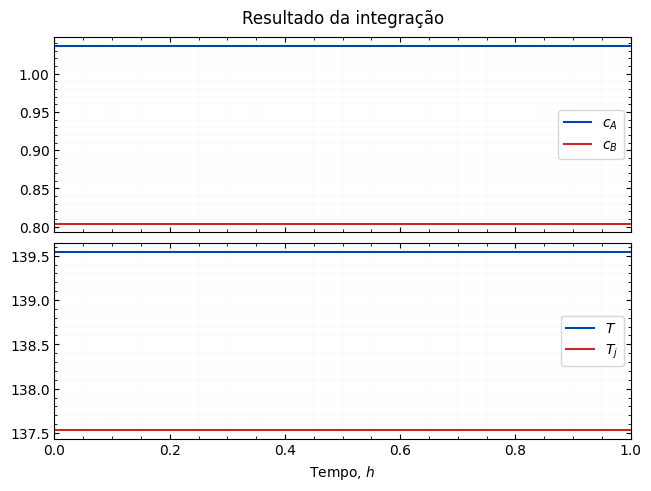

In [48]:
# condição inicial partindo do ponto nominal
x_nom = np.array([1.03617957, 0.80396397, 139.53788821, 137.53788827])
u_nom = np.array([20.0, -2.0, 130])

# intervalo de integração em horas
t_span = np.array([0, 1])

# chamada da integração numérica
t, Y, U = Plant.integrate(t_span=t_span, y0=x_nom, u=u_nom)

# gráfico dos resultados
fig, ax = plt.subplots(2, 1, constrained_layout=True, sharex=True)

ax[0].plot(t, Y.T[0], label="$c_A$", color="#0047AB")
ax[0].plot(t, Y.T[1], label="$c_B$", color="#cc2525")

ax[1].plot(t, Y.T[2], label="$T$", color="#0047AB")
ax[1].plot(t, Y.T[3], label="$T_j$", color="#cc2525")

for a in ax:
    a.tick_params(axis='both', which='both',direction='in', top=True, right=True)
    a.autoscale(enable=True, axis='x', tight=True)

    a.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    a.minorticks_on()

ax[0].legend()
ax[1].legend()

ax[1].set_xlabel("Tempo, $h$")

ax[0].set_title("Resultado da integração", pad=10)

plt.show()

Note que não existe dinâmica nos resultados da integração numérica, ou seja, o estado estacionário calculado realmente é um estado estacionário do sistema.

#### 1.2 Calculando a resposta ao degrau

Agora que já temos um estado estacionário identificado/definido, podemos realizar o teste de resposta ao degrau.

Obter o estado estacionário era um requisito porque agora vamos dar um "degrau" nas variáveis de entrada e coletar os valores das variáveis de saída do sistema.

Vamos aplicar degraus individuais da seguinte forma:

- degrau de `u_nom = [20.0, -2.0]` para `u0 = [21.0, -2.0]`.
- degrau de `u_nom = [20.0, -2.0]` para `u1 = [20.0, -1.0]`.

Note que vamos realizar um degrau unitário e positivo em cada entrada individualmente, mas não existe regra aqui, o degrau poderia ser de qualquer magnitude e ser negativo também.

**Importante**

Os valores da resposta ao degrau precisam estar amostrados no mesmo intervalo de amostragem `dt`que iremos no controlador futuramente, existe um argumento opcional na integração da planta `t_eval` que permite obter a resposta em valores específicos de tempo, então aqui precisamos gerar um vetor com os valores de tempo em que desejamos obter os valores da resposta do sistema.

*Nota: vamos utilizar um intervalo de amostragem de 0.6 minuto.*

Daqui para frente vamos utilizar a seguinte notação para o sistema:

$$
\begin{align*}
c_B \rightarrow y_1 \\
T \rightarrow y_2 \\
F/V \rightarrow u_1 \\
Q \rightarrow u_2 \\
\end{align*}
$$

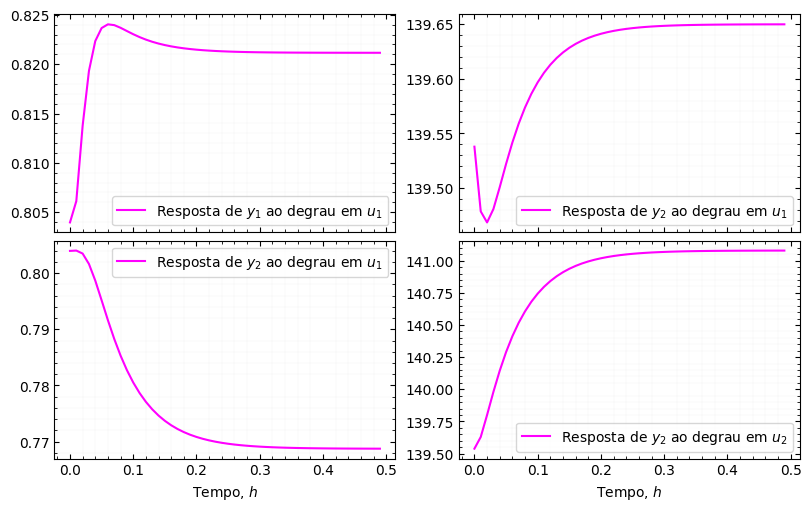

In [49]:
# condição inicial partindo do ponto nominal
x_nom = np.array([1.03617957, 0.80396397, 139.53788821, 137.53788827])
u_nom = np.array([20.0, -2.0, 130])

# vetores para aplicação do degrau na entrada
u0 = np.array([21.0, -2.0, 130])
u1 = np.array([20.0, -1.0, 130])

# criação do vetor t_eval para avaliação da resposta em intervalos específicos
dt = 0.6/60 # tempo de amostragem, aqui é feita a conversão para hora
tf = 0.5    # tempo final de integração
t_eval = np.arange(0, tf, dt)

# teste degrau na primeira entrada
t_span = np.array([0, tf])
t0, Y0, U0 = Plant.integrate(t_span=t_span, t_eval=t_eval, y0=x_nom, u=u0)

# teste degrau na segunda entrada
t_span = np.array([0, tf])
t1, Y1, U1 = Plant.integrate(t_span=t_span, t_eval=t_eval, y0=x_nom, u=u1)

# gráfico dos resultados
fig, ax = plt.subplots(2, 2, figsize=(8, 5), constrained_layout=True, sharex=True)

ax[0, 0].plot(t0, Y0.T[1], label="Resposta de $y_1$ ao degrau em $u_1$", color="magenta")
ax[0, 1].plot(t0, Y0.T[2], label="Resposta de $y_2$ ao degrau em $u_1$", color="magenta")

ax[1, 0].plot(t1, Y1.T[1], label="Resposta de $y_2$ ao degrau em $u_1$", color="magenta")
ax[1, 1].plot(t1, Y1.T[2], label="Resposta de $y_2$ ao degrau em $u_2$", color="magenta")

for a in ax.flatten():
    a.tick_params(axis='both', which='both',direction='in', top=True, right=True)
    # a.autoscale(enable=True, axis='x', tight=True)

    a.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    a.minorticks_on()
    a.legend()

ax[1, 0].set_xlabel("Tempo, $h$")
ax[1, 1].set_xlabel("Tempo, $h$")

plt.show()


Agora precisamos organizar os valores das respostas ao degrau.

`Y0` contém as respostas ao primeiro degrau e `Y1` contém as respostas ao segundo degrau. Esses vetores contém as respostas de todas as variáveis de estado, ou seja, $[x_1, x_2, x_3, x_4]$ que são os estados $[c_A, c_B, T, T_j]$, mas só precisamos dos valores de $[x_2, x_3]$, já que esses estados correspondem as saídas $[y_1, y_2]$ que são as variáveis que desejamos controlar.

- Y0[1] contém a resposta de $y_1$ ao degrau em $u_1$;
- Y0[2] contém a resposta de $y_2$ ao degrau em $u_1$;
- Y1[1] contém a resposta de $y_1$ ao degrau em $u_2$;
- Y1[2] contém a resposta de $y_2$ ao degrau em $u_2$;

Para organizar os valores de forma que possamos usar os códigos que fazem a montagem do modelo, só precisamos colocar os vetores das respostas em uma lista plana, além disso também precisamos criar uma lista com os valores dos degraus que foram aplicados, pois no momento de construir a matriz dinâmica a resposta ao degrau precisa ser normalizada pela magnitude do degrau aplicado.

In [50]:
# lista das respostas ao degrau
# aqui vamos utilizar a transposição ".T" para acessar corretamente os vetores
step_response = [Y0.T[1], Y1.T[1], Y0.T[1], Y1.T[2]] 

# amplitude dos degraus aplicados nas entradas
step_amp = [1.0, 1.0]

Vamos salvar os valores do teste ao degrau usando a função `savez` do `numpy`, essa função serve para salvar vetores e matrizez em formato que o `numpy`consiga ler depois.

In [51]:
np.savez("results\\vdV_step_model.npz", step_response=step_response, step_amp= step_amp)

#### 2. Criação do controlador QDMC.

Para criar o controlador QDMC, primeiramente vamos criar o modelo de resposta ao degrau baseado no teste ao degrau realizado antes.

Para isso vamos utilizar as class `DynamicMatrix` e `StepResponseModel`. Aqui já iremos definir os horizontes de predição e de controle do controlador para criar a matriz dinâmica nas dimensões adequadas.

In [52]:
from src.models import DynamicMatrix, StepResponseModel

# carregar os dados de resposta ao degrau
step_model = np.load(r"results\\vdv_step_model.npz")

# extrair os valores das saídas e das amplitudes dos degraus
Y  = step_model["step_response"]
du = step_model["step_amp"]

# horizontes de predição e de controle
Np = 40
Nc = 4

# criação da matriz dinâmica
dynamic_matrix = DynamicMatrix(Np, Nc, Y, du)

# criação do modelo de resposta ao degrau
model = StepResponseModel(dynamic_matrix)

Agora podemos definir o restante da sintonia do controlador e criar o objeto do controlador chamando a classe `QDMC`.

In [53]:
from src.controllers import QDMC
from src.utils import Logger

Q = np.array([[100.0, 0.0],
              [0.0, 1.0]])

R = np.array([[1.0, 0.0],
              [0.0, 1.0]])

controller = QDMC(
    model,
    Q,
    R,
    Logger(),
)

#### 2. Simulação em malha fechada

Com o controlador criado podemos configurar a simulação em malha fechada.

In [54]:
# numero de intervalos de amostragem
N_STEPS = 800

# valor do tempo de amostragem
dt = 0.6 / 60  # 0.6 min

# limites de incremento
lbdu = np.array([-2.2, -1.2])
ubdu = np.array([2.2, 1.2])

# limites para as entradas
lbu = np.array([10, -10])
ubu = np.array([400, 0])

# limites para as saídas
lby = np.array([0.0, 120])
uby = np.array([1.0, 165])

# valores nominais
x_nom = np.array([1.03617957, 0.80396397, 139.53788821, 137.53788827])
y_nom = np.array([0.80396397, 139.53788821])
u_nom = np.array([20.0, -2.0])

u_k = u_nom.copy()
tk = 0

scenario = 'Servo'

if scenario == "Servo":
    schedule = [
        (0, y_nom, Plant, 130),
        (400, np.array([1.1, 135]), Plant, 130),
    ]

ptr = 0
y_sp = y_nom
y_plant = y_nom.copy()
x_plant = x_nom.copy()

for k in tqdm(range(N_STEPS)):
    while ptr+1 < len(schedule) and k >= schedule[ptr+1][0]:
        ptr += 1
    
    y_sp = schedule[ptr][1]
    Plant = schedule[ptr][2]
    d_meas = schedule[ptr][3]

    delta_u_k = controller(
                    y_sp=y_sp,
                    y_meas=y_plant,
                    u_meas=u_k,
                    lbdu=lbdu,
                    ubdu=ubdu,
                    lbu=lbu,
                    ubu=ubu,
                    lby=lby,
                    uby=uby
                    )[0]

    u_k += delta_u_k

    t_span = np.array([tk, tk + dt])
    t_eval = np.linspace(tk, tk + dt, 501)

    _, x_next, _ = Plant.integrate(t_span=t_span, y0=x_plant, t_eval=t_eval, u=np.append(u_k, d_meas))
    
    x_plant = x_next[-1,:]
    y_plant = x_plant[1:3]
    tk += dt

# log do controlador
log = controller.logger.to_numpy()

100%|██████████| 800/800 [00:00<00:00, 1503.08it/s]


**Nota:** os resultados de operação do controlador são armazenados em um log que pode ser convertido em numpy array usando o método `controller.logger.to_numpy()` o log é organizado na forma de um dicionário e os valores podem ser acessado por meio das chaves:

- ['k']      acessa o contador de tempo discreto do controlador;
- ['y_meas'] acessa os valores medidos das variáveis de saída;
- ['y_sp']   acessa os valores de setpoint que o controlador recebeu;
- ['y_pred'] acessa os valores preditos pelo modelo;
- ['u_meas'] acessa os valores medidos das variáveis de entrada;
- ['move']   acessa os valores de incremento que o controlador calculou.

Exemplo de uso:

`log = controller.logger.to_numpy()`

Acessando os valores das saídas medidas `log['y_meas']`

Lembrando que os valores são organizados de forma vetorial de acordo com o número de variáveis do problema.

Gráfico dos resultados

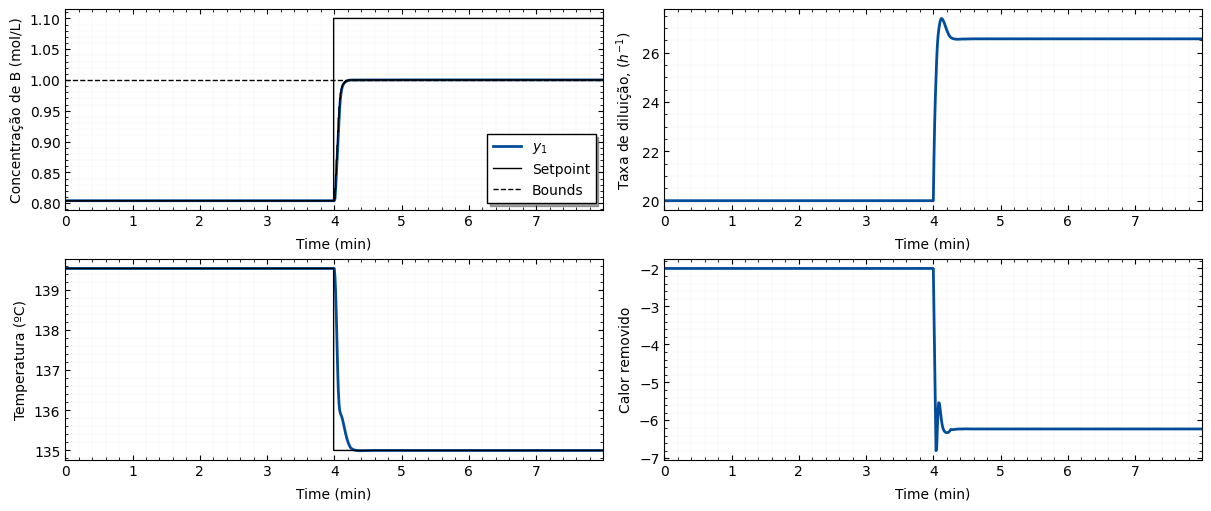

In [55]:
t = log['k'] * dt
y = log['y_meas']
u = log['u_meas']
sp = log['y_sp']

fig, ax = plt.subplots(2, 2, figsize=(12,5), constrained_layout=True)

ax[0, 0].plot(t, y.T[0], color='#034c99', ls='-', lw=2.0, label='$y_1$')
ax[0, 0].step(t, y.T[0], color='k', ls='-', lw=1.0, label='Setpoint')
ax[0, 0].axhline(uby[0], color='k', ls='--', lw=1.0, label="Bounds")

ax[0, 1].plot(t, u.T[0], color='#034c99', ls='-', lw=2.0, label='$y_1$')
ax[1, 1].plot(t, u.T[1], color='#034c99', ls='-', lw=2.0, label='$y_1$')

for a in ax.flatten():
    a.tick_params(axis='both', which='both',direction='in', top=True, right=True)
    a.autoscale(enable=True, axis='x', tight=True)
    
    a.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    a.minorticks_on()
    a.set_xlabel('Time (min)', labelpad=6.0)

ax[0, 0].legend(
    loc = "best",
    ncol = 1,
    frameon = True,
    shadow = True,
    edgecolor= 'k',
    fancybox = False,
) 

ax[0, 0].set_ylabel('Concentração de B (mol/L)')
ax[1, 0].set_ylabel('Temperatura (ºC)')

ax[0, 1].set_ylabel('Taxa de diluição, ($h^{-1}$)')
ax[1, 1].set_ylabel('Calor removido')

ax[1, 0].plot(t, y.T[1], color='#034c99', ls='-', lw=2.0)

ax[0, 0].step(t, sp.T[0], color='k', ls='-', lw=1.0)
ax[1, 0].step(t, sp.T[1], color='k', ls='-', lw=1.0)


plt.show()